In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [3]:
price_files = {
    -2: "./data/prices_round_1_day_-2.csv",
    -1: "./data/prices_round_1_day_-1.csv",
     0: "./data/prices_round_1_day_0.csv"
}

trade_files = {
    -2: "./data/trades_round_1_day_-2.csv",
    -1: "./data/trades_round_1_day_-1.csv",
     0: "./data/trades_round_1_day_0.csv"
}

# Load and offset timestamps by 1M steps
OFFSET = 1_000_000
PepperRoot_prices_full = []
PepperRoot_trades_full = []

for i, (day, pf) in enumerate(price_files.items()):
    df = pd.read_csv(pf, sep=';')
    df = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    PepperRoot_prices_full.append(df)

for i, (day, tf) in enumerate(trade_files.items()):
    df = pd.read_csv(tf, sep=';')
    df = df[df['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    PepperRoot_trades_full.append(df)

# Combine
PepperRoot_prices = pd.concat(PepperRoot_prices_full, ignore_index=True).sort_values('timestamp')
PepperRoot_trades = pd.concat(PepperRoot_trades_full, ignore_index=True).sort_values('timestamp')

len(PepperRoot_prices), len(PepperRoot_trades)
PepperRoot_trades.head(10)


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2
1,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2
2,10500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10013.0,5,-2
3,12600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10018.0,3,-2
4,15000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10021.0,7,-2
5,15600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10021.0,3,-2
6,20200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10026.0,6,-2
7,21500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10027.0,4,-2
8,22600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10019.0,3,-2
9,22600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10019.0,4,-2


<Figure size 1600x600 with 0 Axes>

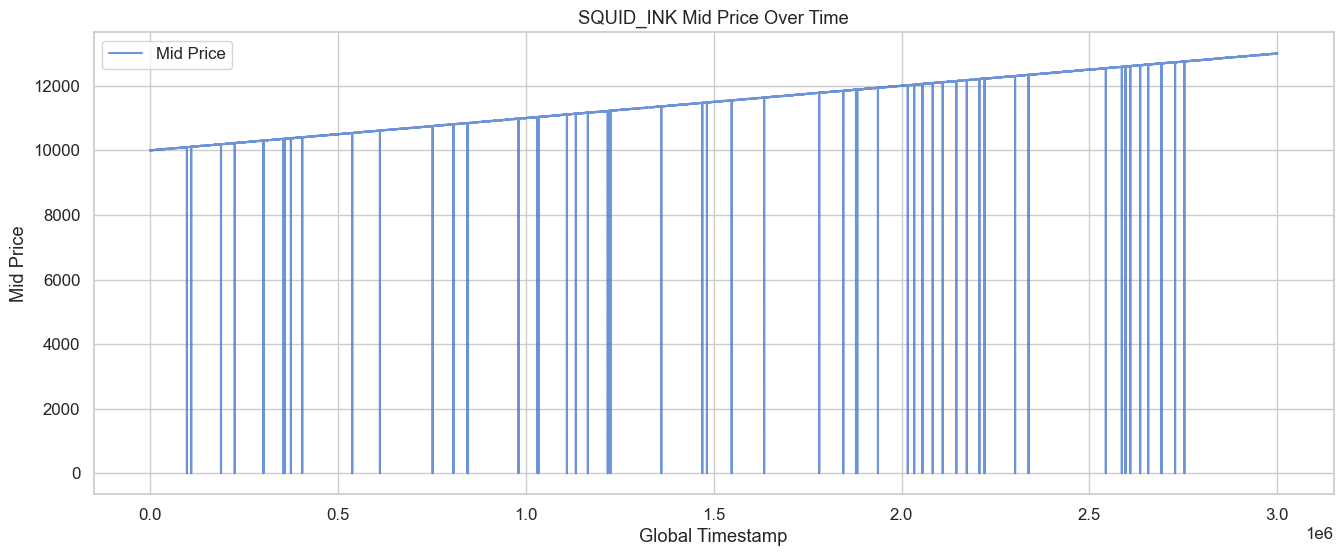

In [5]:
# Mid price over time
PepperRoot_prices['mid_price'] = PepperRoot_prices['mid_price']

plt.figure(figsize=(16, 6))
plt.plot(PepperRoot_prices['timestamp'], PepperRoot_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('SQUID_INK Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

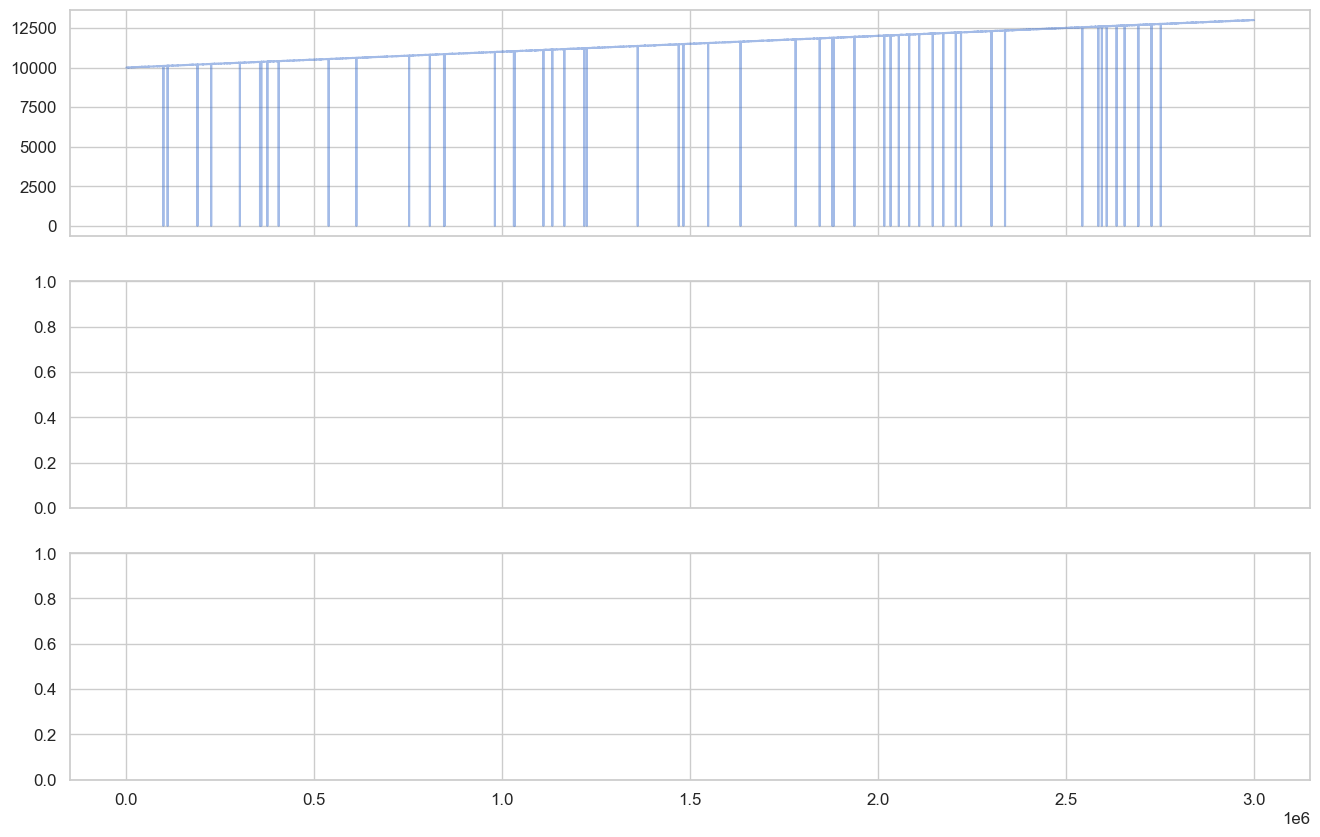

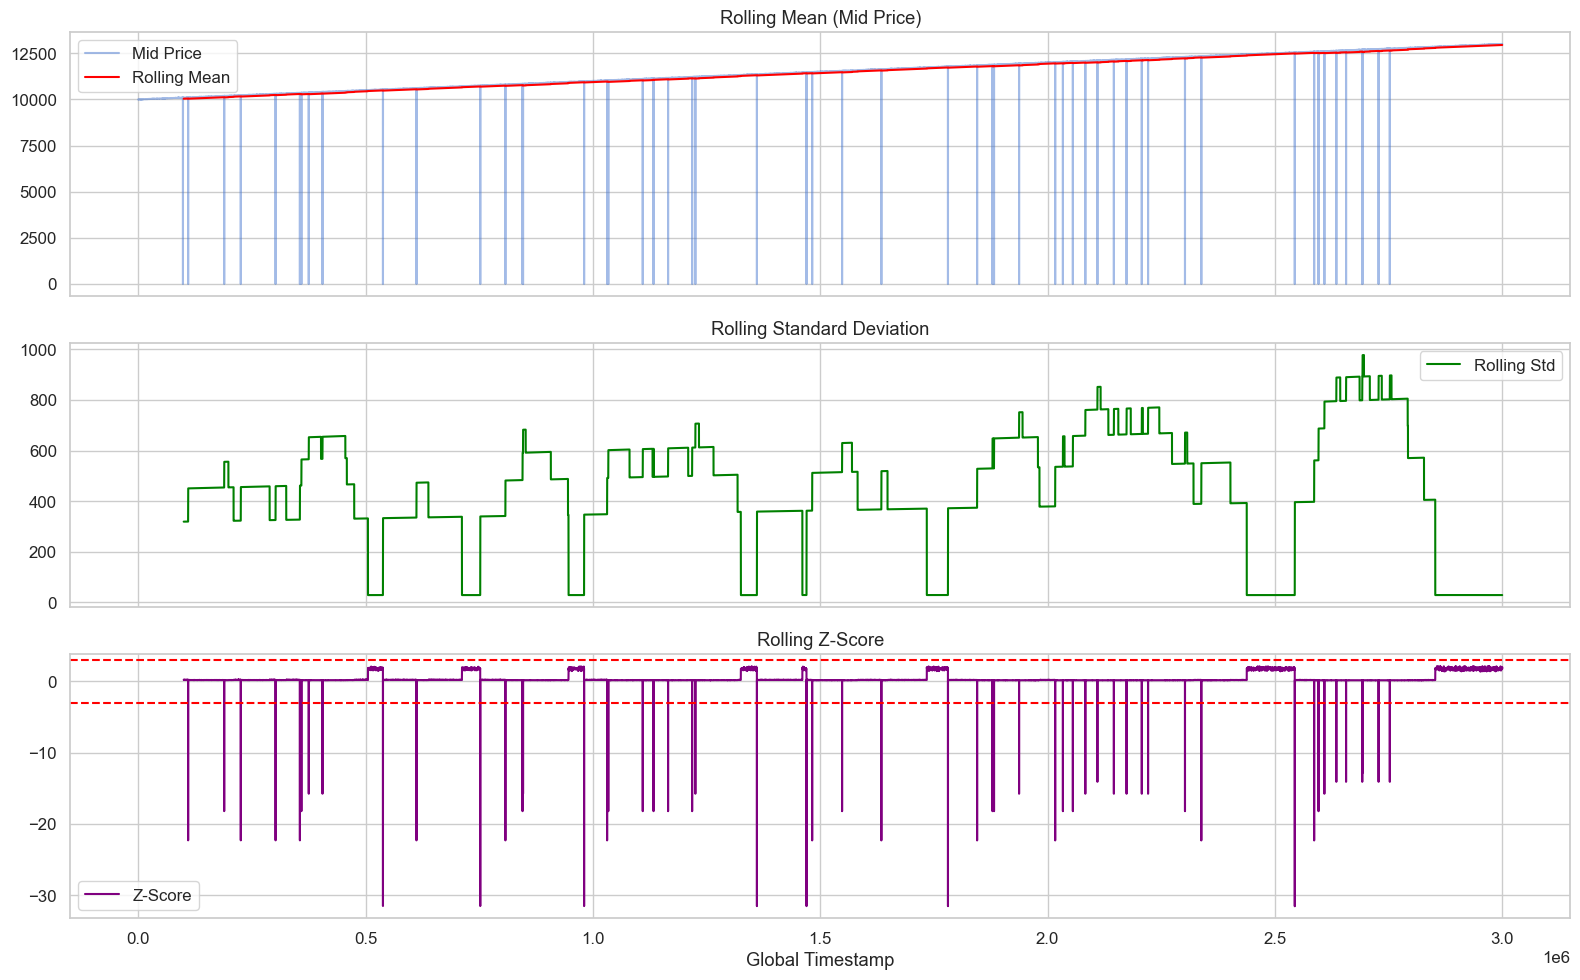

In [10]:
# Rolling stats
WINDOW = 1000 #10 values
PepperRoot_prices['rolling_mean'] = PepperRoot_prices['mid_price'].rolling(WINDOW).mean()
PepperRoot_prices['rolling_std'] = PepperRoot_prices['mid_price'].rolling(WINDOW).std()
PepperRoot_prices['z_score'] = (PepperRoot_prices['mid_price'] - PepperRoot_prices['rolling_mean']) / PepperRoot_prices['rolling_std']


fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# plot rolling mean, atop of price
axs[0].plot(PepperRoot_prices['timestamp'], PepperRoot_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(PepperRoot_prices['timestamp'], PepperRoot_prices['rolling_mean'], label='Rolling Mean',color='red')
axs[0].set_title('Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(PepperRoot_prices['timestamp'], PepperRoot_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(PepperRoot_prices['timestamp'], PepperRoot_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='red', linestyle='--')
axs[2].axhline(-3, color='red', linestyle='--')
axs[2].set_title('Rolling Z-Score')
axs[2].legend()

plt.xlabel('Global Timestamp')
plt.tight_layout()
plt.show()

## This is the analysis for Osmium

In [15]:
# Load and offset timestamps by 1M steps
OFFSET = 1_000_000
Osmium_prices_full = []
Osmium_trades_full = []

for i, (day, pf) in enumerate(price_files.items()):
    df = pd.read_csv(pf, sep=';')
    df = df[df['product'] == 'ASH_COATED_OSMIUM'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    Osmium_prices_full.append(df)

for i, (day, tf) in enumerate(trade_files.items()):
    df = pd.read_csv(tf, sep=';')
    df = df[df['symbol'] == 'ASH_COATED_OSMIUM'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    Osmium_trades_full.append(df)

# Combine
Osmium_prices = pd.concat(Osmium_prices_full, ignore_index=True).sort_values('timestamp')
Osmium_trades = pd.concat(Osmium_trades_full, ignore_index=True).sort_values('timestamp')

len(Osmium_prices), len(Osmium_trades)
Osmium_trades.head(10)

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2
2,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2
3,6100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10013.0,8,-2
4,12900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,9,-2
5,13800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10017.0,3,-2
6,15000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10016.0,3,-2
7,15100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10016.0,5,-2
8,15900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9995.0,9,-2
9,17400,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10014.0,4,-2


In [18]:
Osmium_prices.head(10)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0
5,-2,500,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,30.0,NaN,NaN,10008.0,13.0,10010.0,30.0,NaN,NaN,10000.0,0.0
6,-2,600,ASH_COATED_OSMIUM,9989.0,30.0,NaN,NaN,NaN,NaN,10010.0,30.0,NaN,NaN,NaN,NaN,9999.5,0.0
7,-2,700,ASH_COATED_OSMIUM,9990.0,27.0,NaN,NaN,NaN,NaN,10011.0,27.0,NaN,NaN,NaN,NaN,10000.5,0.0
8,-2,800,ASH_COATED_OSMIUM,9993.0,15.0,NaN,NaN,NaN,NaN,10011.0,21.0,NaN,NaN,NaN,NaN,10002.0,0.0
9,-2,900,ASH_COATED_OSMIUM,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,8.0,10009.0,13.0,10011.0,30.0,9995.5,0.0


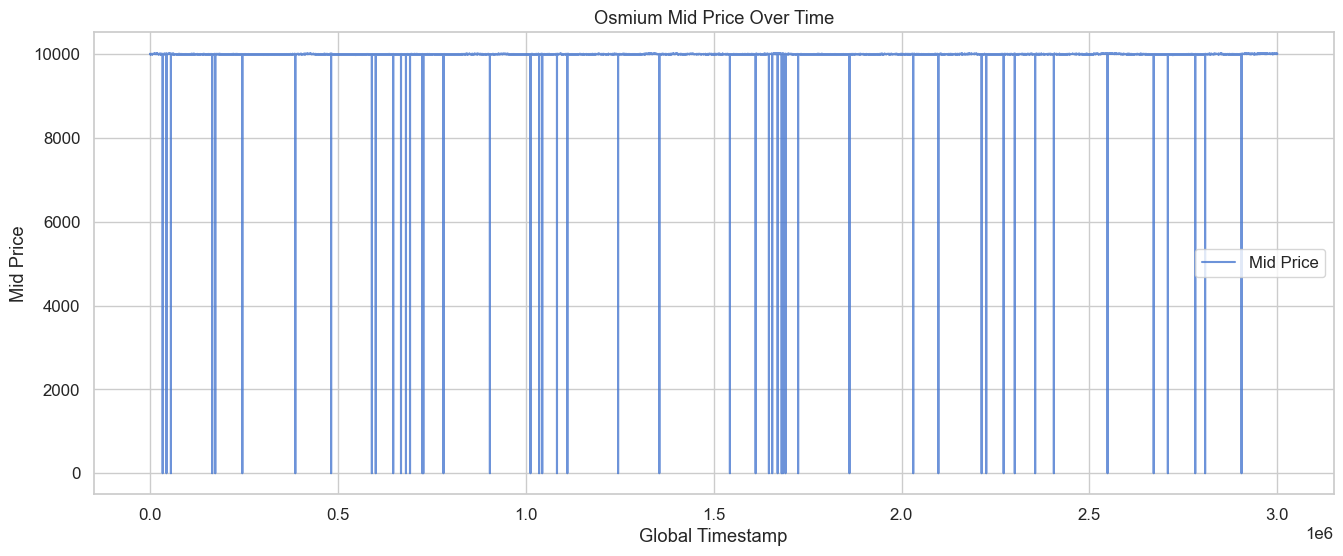

In [16]:
# Mid price over time
Osmium_prices['mid_price'] = Osmium_prices['mid_price']

plt.figure(figsize=(16, 6))
plt.plot(Osmium_prices['timestamp'], Osmium_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('Osmium Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

In [21]:
Osmium_prices[Osmium_prices['mid_price'] < 4000]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
338,-2,33800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
438,-2,43800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
557,-2,55700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1655,-2,165500,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1737,-2,173700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2457,-2,245700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3867,-2,386700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4820,-2,482000,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5905,-2,590500,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
6008,-2,600800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


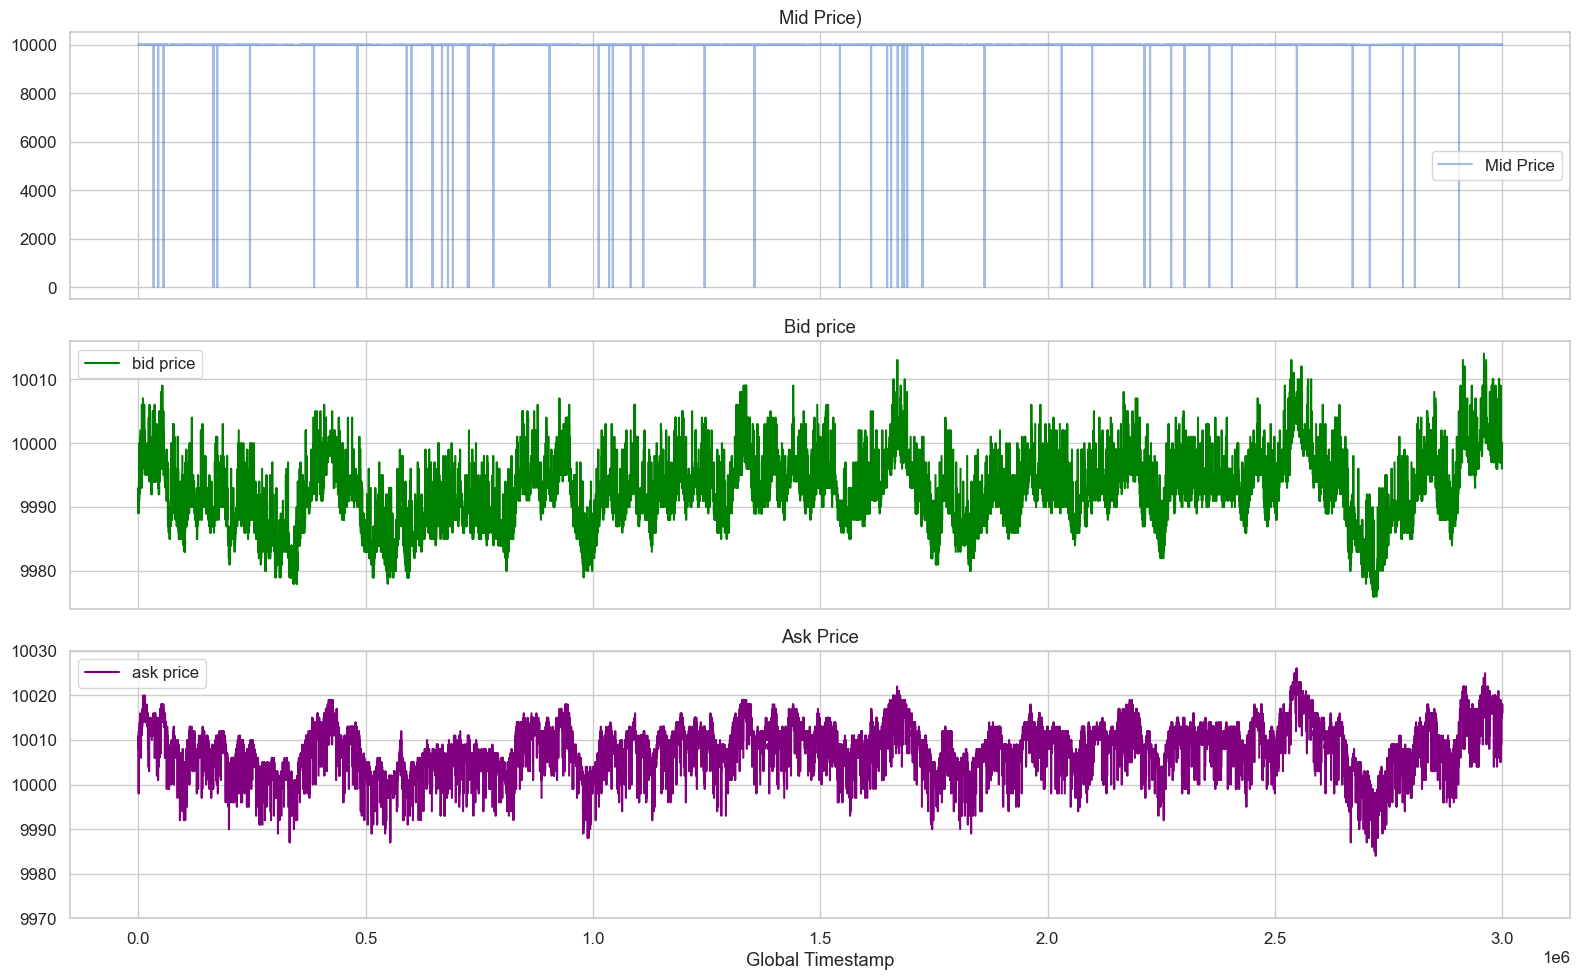

In [35]:
fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
# plot mid price, bid and ask
axs[0].plot(Osmium_prices['timestamp'], Osmium_prices['mid_price'], label='Mid Price', alpha=0.5)
#axs[0].plot(Osmium_prices['timestamp'], Osmium_prices['rolling_mean'], label='Rolling Mean',color='red')
axs[0].set_title('Mid Price)')
axs[0].legend()
#axs[0].ylim(9900,10100)
axs[1].plot(Osmium_prices['timestamp'], Osmium_prices['bid_price_1'], label='bid price', color='green')
axs[1].set_title('Bid price')
axs[1].legend()
#axs[1].ylim(9900,10100)
axs[2].plot(Osmium_prices['timestamp'], Osmium_prices['ask_price_1'], label='ask price', color='purple')
axs[2].axhline(3, color='red', linestyle='--')
axs[2].axhline(-3, color='red', linestyle='--')
axs[2].set_title('Ask Price')
axs[2].legend()

plt.ylim(9970,10030)
plt.xlabel('Global Timestamp')
plt.tight_layout()
plt.show()

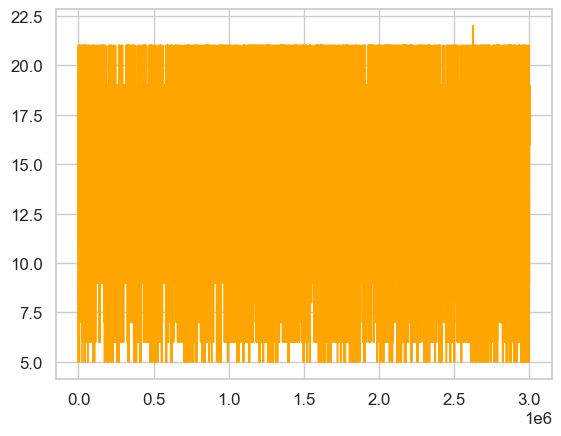

In [30]:
Osmium_prices['spread'] = Osmium_prices['ask_price_1'] - Osmium_prices['bid_price_1']
plt.plot(Osmium_prices['timestamp'], Osmium_prices['spread'], label='spread', color='orange')
plt.show()

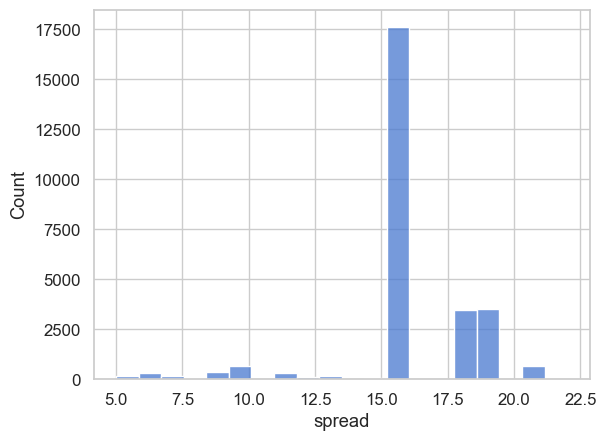

In [37]:
sns.histplot(Osmium_prices['spread'], bins=20)
plt.show()